# Woche 1 – Freitag: Äquivalenz von Normen & Michigan W1

## Block 1 (06:00 – 08:45): Äquivalenz von Normen (maschinelle Verifikation)

**Lernziel:** Sie können die Äquivalenz von Normen in $\mathbb{R}^n$ durch maschinelle Prüfung der Ungleichungskette für ein konkretes Beispiel verifizieren.

**Satz:** In $\mathbb{R}^n$ sind alle Normen äquivalent: Für zwei beliebige Normen $\|\cdot\|_a$ und $\|\cdot\|_b$ existieren Konstanten $c, C > 0$, so dass für alle $x \in \mathbb{R}^n$:

$$c \|x\|_a \le \|x\|_b \le C \|x\|_a.$$

Für die $\ell_1$, $\ell_2$ und $\ell_\infty$‑Normen gilt insbesondere:

$$\|x\|_\infty \le \|x\|_2 \le \|x\|_1 \le n \|x\|_\infty.$$

**Aufgabe:** Überprüfen Sie die Ungleichungskette für $x = (1, 2, 3)$ mit Python und `assert`-Anweisungen.

```python


In [2]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])
n = len(x)

norm_inf = np.linalg.norm(x, ord=np.inf)
norm_2 = np.linalg.norm(x, ord=2)
norm_1 = np.linalg.norm(x, ord=1)

# Maschinelle Prüfung der Ungleichungskette
assert norm_inf <= norm_2, f"ℓ∞ ≤ ℓ2 verletzt: {norm_inf} > {norm_2}"
assert norm_2 <= norm_1, f"ℓ2 ≤ ℓ1 verletzt: {norm_2} > {norm_1}"
assert norm_1 <= n * norm_inf, f"ℓ1 ≤ n·ℓ∞ verletzt: {norm_1} > {n * norm_inf}"

print("Alle Ungleichungen der Norm-Äquivalenz erfolgreich verifiziert.")

Alle Ungleichungen der Norm-Äquivalenz erfolgreich verifiziert.


## Block 2 (09:30 – 11:40): Michigan W1 – Erweiterung von `05_Pandas_Data_Analysis.ipynb`

**Lernziel:**Sie können eine Datenanalyse-Pipeline mit Integritätsprüfungen, Aggregationen und Visualisierung implementieren.

Öffnen Sie das Notebook `05_Pandas_Data_Analysis.ipynb` (aus Ihrem Track A) und erweitern Sie es um die folgenden Analysen:

1. Höchste Transaktionen (sortiert nach `amount` absteigend, Top 3).
2. Filter nach `amount > 2000` und Ausgabe der Status‑Verteilung.
3. Histogramm der Beträge mit `matplotlib`.

**Hinweis:** Sie können die Code‑Zellen aus dem vorherigen Tag (Donnerstag) als Vorlage nutzen.
Die assert-Prüfungen stellen die Datenintegrität sicher – ein Standard in produktiven Data‑Science‑Pipelines.

Top 3 Transaktionen (Betrag absteigend):
   tx_id   amount status
1    102  12000.0  alert
3    104   8500.0  alert
4    105   3200.0  alert

Statusverteilung bei Betrag > 2000:
status
alert    3
Name: count, dtype: int64


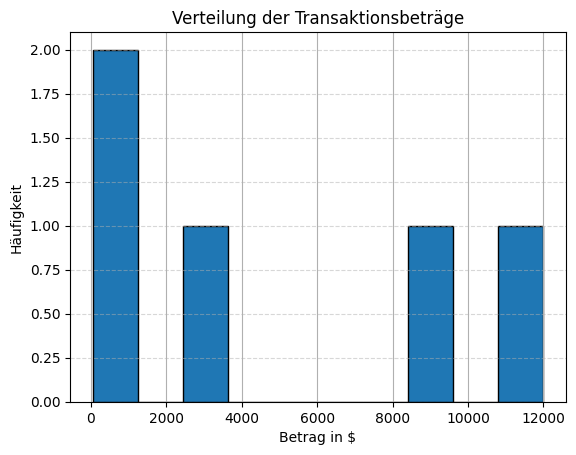

In [3]:
# Beispiel für die Erweiterung (falls Sie das Notebook direkt hier ausführen möchten)
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden mit Fallback
try:
    df = pd.read_json('cleaned_aml_batch.json')
except FileNotFoundError:
    # Reproduzierbarer Mock-Datensatz, falls JSON nicht existiert
    df = pd.DataFrame({
        'tx_id': [101, 102, 103, 104, 105],
        'amount': [150.0, 12000.0, 45.0, 8500.0, 3200.0],
        'status': ['clean', 'alert', 'clean', 'alert', 'alert']
    })

# 1. Top 3 Transaktionen
top3 = df.sort_values('amount', ascending=False).head(3)
print("Top 3 Transaktionen (Betrag absteigend):")
print(top3[['tx_id', 'amount', 'status']])

# 2. Filter und Statusverteilung
high = df[df['amount'] > 2000]
print("\nStatusverteilung bei Betrag > 2000:")
print(high['status'].value_counts())

# 3. Histogramm
df['amount'].hist(bins=10, edgecolor='black')
plt.title('Verteilung der Transaktionsbeträge')
plt.xlabel('Betrag in $')
plt.ylabel('Häufigkeit')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Maschinelle Plausibilitätsprüfung
assert not df.empty, "DataFrame ist leer"
assert df['amount'].dtype == 'float64', "Spalte 'amount' nicht numerisch"
assert df['status'].dtype == 'object', "Spalte 'status' nicht kategorial"

## Block 3 (12:40 – 14:10): GOV – Offene Rechtsfragen zur KI‑Kompetenz (Art. 4)

**Lernziel:** Sie können praktische Implementierungslücken des AI Act identifizieren und als strukturierte Fragen für die Rechtsabteilung aufbereiten.

**Hintergrund:** Am Dienstag haben Sie die **Subsumtionsmatrix** (Art. 3) erstellt. Heute konkretisieren Sie die Anwendung von **Art. 4** (KI‑Kompetenz) auf Ihr AML‑System.

**Aufgabe:** Verfassen Sie eine Datei `04_offene_fragen_art4.md` im Ordner `01_Master_Curriculum_DS_ML/Track_C_Governance_and_Compliance` mit mindestens drei offenen Fragen, die eine Bank an ihre Rechtsabteilung richten müsste. Beispiele:

- *Müssen externe Dienstleister (z. B. Cloud‑Anbieter), die das KI‑System hosten, ebenfalls über KI‑Kompetenz verfügen?*
- *Reichen interne Schulungsvideos oder sind externe Zertifizierungen (z. B. nach ISO/IEC 42001) erforderlich?*
- *Wie ist der Nachweis der KI‑Kompetenz im Falle einer aufsichtlichen Prüfung (BaFin) zu dokumentieren?*
- *Welche Fristen gelten für die Nachschulung von Mitarbeitern bei Modellupdates?*

Speichern Sie die Fragen als Markdown‑Liste.

---

## Block 4 (14:40 – 16:00): SPR – Wissenschaftliche Synthese (Nominalstil)

**Lernziel:** Sie können die Lerninhalte der ersten Woche in einem eigenständigen Portfolio‑Dokument unter maximaler Informationsdichte (Nominalstil) zusammenfassen.

**Aufgabe:** Verfassen Sie eine Datei `LESSONS_LEARNED_WOCHE1.md` im Ordner `02_17_Week_Sprint/Woche_1/`. Die Datei soll die wichtigsten Erkenntnisse aus den vier Blöcken der Woche enthalten:

- Vektorraumaxiome, Normen, Metriken
- NumPy‑ und PyTorch‑Tensoren
- AI Act (Art. 1–4, Subsumtion)
- Nominalstil in der Compliance‑Kommunikation

**Restriktionen:**
- **Länge:** Maximal 250 Wörter.
- **Grammatik:** Zwingende Vermeidung von Nebensätzen (`dass`, `weil`, `wenn`) durch vollständige Nominalisierung.
- **Stil:** Keine persönlichen Pronomen („ich“, „wir“). Verwenden Sie das Passiv oder Passiv‑Ersatzformen.

**Referenzbeispiel (aus dem Donnerstag):**

> *„Die Klassifizierung des Modells als Hochrisiko‑KI bedingt die Sicherstellung einer korrekten PyTorch‑Tensorberechnung durch die Bank als Betreiber.“*

**Hinweis:** Die Hueber‑Lektüre („Digitalisierung im Bankwesen“) kann als Inspiration für Formulierungen dienen, ist aber nicht Gegenstand der Abgabe.

**Speicherort:** `02_17_Week_Sprint/Woche_1/LESSONS_LEARNED_WOCHE1.md`